<a href="https://colab.research.google.com/github/saswanth01/MLA0304/blob/main/Lab/21_25_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

21

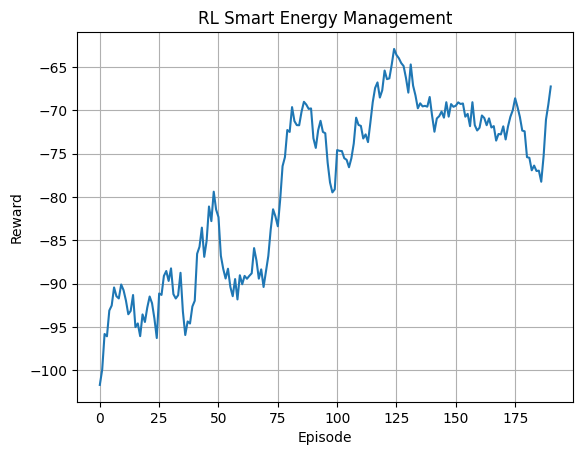

Final Average Reward: -67.24


In [ ]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Smart Energy Environment
class EnergyEnv:
    def reset(self):
        self.demand = np.random.uniform(1,10)
        self.solar = np.random.uniform(0,5)
        self.battery = 5
        return np.array(
            [self.demand,self.solar,self.battery],
            dtype=np.float32
        )

    def step(self, action):
        # 0=Save, 1=Normal, 2=Use Battery
        use = [0,1,2][action]

        grid = max(
            0,
            self.demand - self.solar - use
        )

        self.battery = np.clip(
            self.battery + self.solar - use,
            0, 10
        )

        # Cost + safety + fairness
        cost = grid
        safety = max(0, self.demand-use-8)
        fairness = abs(
            self.demand - use - 5
        )

        reward = -(
            cost +
            2*safety +
            0.2*fairness
        )

        self.demand = np.random.uniform(1,10)
        self.solar = np.random.uniform(0,5)

        return np.array(
            [self.demand,self.solar,self.battery],
            dtype=np.float32
        ), reward


# RL Policy
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,32),
            nn.ReLU(),
            nn.Linear(32,3),
            nn.Softmax(-1)
        )

    def forward(self,x):
        return self.net(x)


env = EnergyEnv()
policy = Policy()
optimizer = optim.Adam(
    policy.parameters(),lr=.001
)

rewards = []

# REINFORCE Training
for episode in range(200):

    state = env.reset()
    loss = 0
    total = 0

    for step in range(30):

        s = torch.tensor(
            state
        ).float()

        dist = torch.distributions.Categorical(
            policy(s)
        )

        action = dist.sample()

        state,r = env.step(
            action.item()
        )

        loss += -dist.log_prob(action)*r
        total += r

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    rewards.append(total)

# Result
plt.plot(
    np.convolve(
        rewards,
        np.ones(10)/10,
        mode="valid"
    )
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("RL Smart Energy Management")
plt.grid()
plt.show()

print(
    "Final Average Reward:",
    round(np.mean(rewards[-10:]),2)
)

22

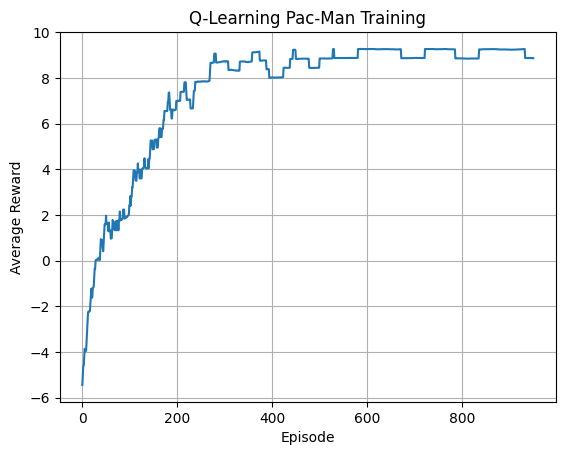

Successful Games: 100 / 100
Average Evaluation Reward: 10.0


In [ ]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
import random

# Grid: 5x5
N = 5
ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]
Q = np.zeros((N,N,N,N,4))

alpha = 0.1
gamma = 0.9
epsilon = 1.0

def reset():
    player = (0,0)
    food = (4,4)
    ghost = (2,2)
    return player, food, ghost

def train(episodes=1000):
    global epsilon

    rewards = []

    for ep in range(episodes):
        player, food, ghost = reset()
        total = 0

        for step in range(50):

            s = (*player, *food)

            # Epsilon-greedy action
            if random.random() < epsilon:
                action = random.randrange(4)
            else:
                action = np.argmax(Q[s])

            dx, dy = ACTIONS[action]

            new_player = (
                np.clip(player[0]+dx,0,N-1),
                np.clip(player[1]+dy,0,N-1)
            )

            # Reward
            if new_player == ghost:
                reward = -10
                done = True

            elif new_player == food:
                reward = 10
                done = True

            else:
                reward = -0.1
                done = False

            ns = (*new_player, *food)

            Q[s+(action,)] += alpha * (
                reward +
                gamma*np.max(Q[ns]) -
                Q[s+(action,)]
            )

            player = new_player
            total += reward

            if done:
                break

        epsilon = max(0.05, epsilon*0.995)
        rewards.append(total)

    return rewards


# Train
rewards = train()

# Training graph
plt.plot(
    np.convolve(
        rewards,
        np.ones(50)/50,
        mode="valid"
    )
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Pac-Man Training")
plt.grid()
plt.show()


# Evaluation
wins = 0
total_reward = 0

for _ in range(100):

    player, food, ghost = reset()

    for step in range(50):

        s = (*player, *food)
        action = np.argmax(Q[s])

        dx, dy = ACTIONS[action]

        player = (
            np.clip(player[0]+dx,0,N-1),
            np.clip(player[1]+dy,0,N-1)
        )

        if player == food:
            wins += 1
            total_reward += 10
            break

        if player == ghost:
            total_reward -= 10
            break

print("Successful Games:", wins, "/ 100")
print("Average Evaluation Reward:", total_reward/100)

23

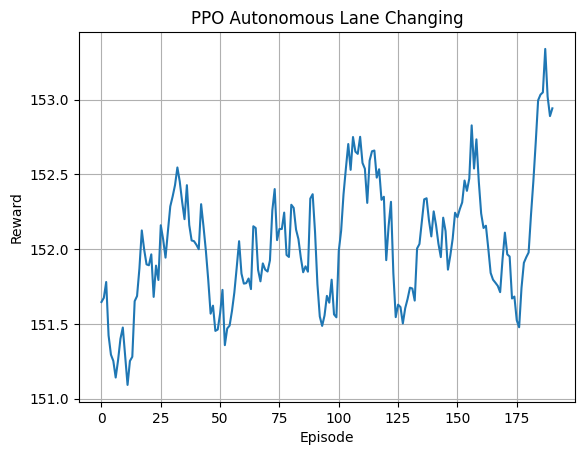

Final Average Reward: 152.94


In [ ]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Highway Environment
class Highway:
    def reset(self):
        self.lane = 1
        self.speed = 5.0
        self.position = 0.0
        self.slow = np.random.uniform(2,4)
        return np.array([self.lane,self.speed,self.slow],dtype=np.float32)

    def step(self, action):
        # 0 = Left, 1 = Stay, 2 = Right
        if action == 0:
            self.lane = max(0,self.lane-1)
        elif action == 2:
            self.lane = min(2,self.lane+1)

        # Slow traffic
        if self.lane == 1:
            self.speed = min(self.speed, self.slow)
        else:
            self.speed = min(7,self.speed+0.2)

        self.position += self.speed
        reward = self.speed

        if self.position >= 100:
            reward += 50
            done = True
        else:
            done = False

        return np.array(
            [self.lane,self.speed,self.slow],
            dtype=np.float32
        ), reward, done


# PPO Network
class PPO(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,32),
            nn.ReLU(),
            nn.Linear(32,3)
        )
        self.value = nn.Linear(3,1)

    def forward(self,x):
        logits = self.net(x)
        value = self.value(x)
        return logits,value


env = Highway()
model = PPO()
optimizer = optim.Adam(model.parameters(),lr=.001)

rewards = []

# PPO Training
for episode in range(200):

    state = env.reset()
    states,actions,old_probs,rs = [],[],[],[]

    for step in range(50):

        s = torch.tensor(state).float()
        logits,value = model(s)
        dist = torch.distributions.Categorical(logits=logits)

        action = dist.sample()

        next_state,r,done = env.step(
            action.item()
        )

        states.append(state)
        actions.append(action.item())
        old_probs.append(
            dist.log_prob(action).detach()
        )
        rs.append(r)

        state = next_state

        if done:
            break

    returns=[]
    G=0

    for r in rs[::-1]:
        G=r+.99*G
        returns.insert(0,G)

    states=torch.tensor(
        np.array(states)
    ).float()

    actions=torch.tensor(actions)
    returns=torch.tensor(
        returns
    ).float()

    old_probs=torch.stack(old_probs)

    logits,values=model(states)

    dist=torch.distributions.Categorical(
        logits=logits
    )

    new_probs=dist.log_prob(actions)

    ratio=torch.exp(
        new_probs-old_probs
    )

    advantage=returns-values.squeeze().detach()

    clipped=torch.clamp(
        ratio,.8,1.2
    )

    loss=-torch.min(
        ratio*advantage,
        clipped*advantage
    ).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    rewards.append(sum(rs))

# Training Graph
plt.plot(
    np.convolve(
        rewards,
        np.ones(10)/10,
        mode="valid"
    )
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Autonomous Lane Changing")
plt.grid()
plt.show()

print(
    "Final Average Reward:",
    round(np.mean(rewards[-10:]),2)
)

24

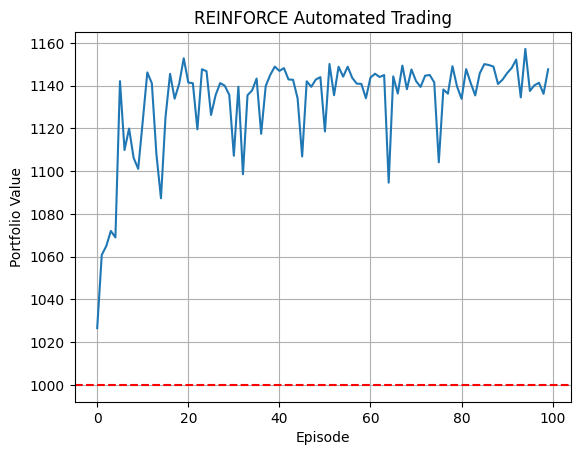

Initial Capital: $1000
Final Value: $ 1147.65
Profit: $ 147.65


In [7]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Market data
np.random.seed(1)
prices = 100 + np.cumsum(np.random.randn(500) * 0.5)

# Policy Network
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Softmax(-1)
        )

    def forward(self, x):
        return self.net(x)

model = Policy()
optimizer = optim.Adam(model.parameters(), lr=0.001)
gamma = 0.99
results = []

# REINFORCE Training
for episode in range(100):

    cash, shares = 1000, 0
    log_probs, rewards = [], []

    for t in range(1, len(prices)-1):

        state = torch.tensor([
            prices[t]/100,
            (prices[t]-prices[t-1])/100,
            shares
        ]).float()

        dist = torch.distributions.Categorical(
            model(state)
        )
        action = dist.sample()

        old_value = cash + shares * prices[t]

        # 0=Buy, 1=Hold, 2=Sell
        if action.item() == 0 and cash >= prices[t]:
            cash -= prices[t]
            shares += 1
        elif action.item() == 2 and shares > 0:
            cash += prices[t]
            shares -= 1

        new_value = cash + shares * prices[t+1]

        reward = new_value - old_value

        # Risk penalty
        reward -= 0.01 * abs(
            prices[t] - prices[t-1]
        )

        log_probs.append(
            dist.log_prob(action)
        )
        rewards.append(reward)

    # Discounted returns
    G, returns = 0, []

    for r in rewards[::-1]:
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(
        returns, dtype=torch.float32
    )

    returns = (
        returns - returns.mean()
    ) / (returns.std() + 1e-8)

    loss = sum(
        -lp * G
        for lp, G in zip(log_probs, returns)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    results.append(
        cash + shares * prices[-1]
    )

# Plot
plt.plot(results)
plt.axhline(1000, color="red", linestyle="--")
plt.xlabel("Episode")
plt.ylabel("Portfolio Value")
plt.title("REINFORCE Automated Trading")
plt.grid()
plt.show()

print("Initial Capital: $1000")
print("Final Value: $", round(results[-1], 2))
print("Profit: $", round(results[-1] - 1000, 2))

25

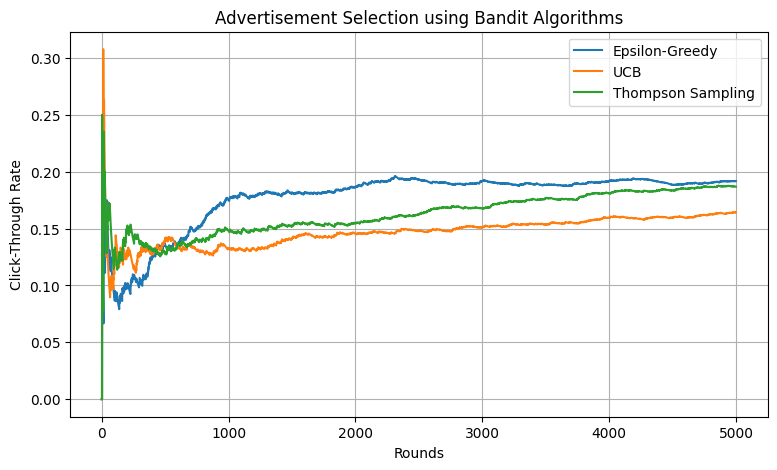

Final CTR
Epsilon-Greedy : 0.1918
UCB             : 0.1642
Thompson        : 0.1868

Best Algorithm: Epsilon-Greedy


In [ ]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# True CTR of 5 advertisements
ctr = [0.05, 0.10, 0.15, 0.08, 0.20]
ads = len(ctr)
rounds = 5000


# Epsilon-Greedy
def epsilon_greedy(eps=0.1):
    clicks = np.zeros(ads)
    shows = np.zeros(ads)
    total = []

    for t in range(rounds):
        if np.random.rand() < eps:
            a = np.random.randint(ads)
        else:
            a = np.argmax(
                clicks / np.maximum(shows, 1)
            )

        click = np.random.rand() < ctr[a]
        clicks[a] += click
        shows[a] += 1
        total.append(click)

    return np.cumsum(total) / np.arange(1, rounds+1)


# UCB
def ucb():
    clicks = np.zeros(ads)
    shows = np.zeros(ads)
    total = []

    for t in range(rounds):
        if t < ads:
            a = t
        else:
            mean = clicks / shows
            bonus = np.sqrt(
                2 * np.log(t+1) / shows
            )
            a = np.argmax(mean + bonus)

        click = np.random.rand() < ctr[a]
        clicks[a] += click
        shows[a] += 1
        total.append(click)

    return np.cumsum(total) / np.arange(1, rounds+1)


# Thompson Sampling
def thompson():
    success = np.ones(ads)
    failure = np.ones(ads)
    total = []

    for t in range(rounds):

        samples = np.random.beta(
            success,
            failure
        )

        a = np.argmax(samples)

        click = np.random.rand() < ctr[a]

        success[a] += click
        failure[a] += 1 - click
        total.append(click)

    return np.cumsum(total) / np.arange(1, rounds+1)


# Run algorithms
eg = epsilon_greedy()
ucb_result = ucb()
ts = thompson()

# Plot CTR
plt.figure(figsize=(9,5))

plt.plot(eg, label="Epsilon-Greedy")
plt.plot(ucb_result, label="UCB")
plt.plot(ts, label="Thompson Sampling")

plt.xlabel("Rounds")
plt.ylabel("Click-Through Rate")
plt.title("Advertisement Selection using Bandit Algorithms")
plt.legend()
plt.grid()
plt.show()

# Final results
print("Final CTR")
print("Epsilon-Greedy :", round(eg[-1], 4))
print("UCB             :", round(ucb_result[-1], 4))
print("Thompson        :", round(ts[-1], 4))

best = np.argmax([
    eg[-1],
    ucb_result[-1],
    ts[-1]
])

print("\nBest Algorithm:",
      ["Epsilon-Greedy", "UCB", "Thompson Sampling"][best])